## Codes to do various tiny things

In [ ]:
## Saving a tuple using pickle!
import random
import pickle
rng = random.Random()
rng.seed(42)
state = rng.getstate()

with open('state_1.pkl', 'wb') as f:
    pickle.dump(state, f)

with open('state_1.pkl', 'rb') as f:
    state_1 = pickle.load(f)

print(state_1)


In [ ]:
## Saving the matrices into .csv files
import numpy as np
from numpy import ndarray

rho = np.load('Data_1/rho1001.npy')
rho = ndarray.round(rho,2)
np.savetxt('Text/rho1001.csv',rho, fmt='%.2f' , delimiter = ',') 
print(rho)

In [ ]:
## How to do a Bar plot!
import matplotlib.pyplot as plt

# Sample data
categories = ['A', 'B', 'C', 'D']
values = [10, 15, 7, 12]

# Create the bar chart
plt.bar(categories, values, color='skyblue')

# Add labels and title
plt.xlabel('Categories')
plt.ylabel('Values')
plt.title('Bar Chart Example')

# Display the chart
plt.show()

In [ ]:
## How to plot a color mesh
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(-5, 5, 0.25)
y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

fig, ax = plt.subplots()
mesh = ax.pcolormesh(X, Y, Z, shading='gouraud', cmap='viridis')
fig.colorbar(mesh)
plt.show()

In [ ]:
## mesh plot with semilog axes!
import matplotlib.pyplot as plt
import numpy as np

# Sample data
a = np.log10(0.5)
b = np.log10(128)
x = np.logspace(a, b, 100)
y = np.linspace(0, 50, 51)
#y = (1,5,10,15,20,25,30,35,40,45,50)
z = np.random.rand(51, 100)

# Create the figure and axes
fig, ax = plt.subplots()

# Plot the pcolormesh
mesh = ax.pcolormesh(x, y, z, shading='gouraud')

# Set x-axis to logarithmic scale
ax.set_xscale('log')

# Add a colorbar
fig.colorbar(mesh)

# Set labels and title
ax.set_xlabel('X-axis (log scale)')
ax.set_ylabel('Y-axis')
ax.set_title('Semilog pcolormesh Plot')

# Show the plot
plt.show()

In [ ]:
## How to print to a file
import numpy as np
with open('output.txt', 'w') as f:
    for i in range(13):
        A = np.load(f'Data_2/Ham{i+1}000.npy')
        print(f'Ham{i+1}000 loaded!', file=f)

with open('output.txt', 'a') as f:
    print('Meet you again', file=f)


In [ ]:
## MG series using reservoirpy module!
from reservoirpy.datasets import mackey_glass
import matplotlib.pyplot as plt
import numpy as np

# Generate 15000 timesteps with default parameters (tau=17, a=0.2, b=0.1, n=10)
mg_series_reservoirpy = mackey_glass(15000, tau=17, a=0.2, b=0.1, n=10)
a = np.max(mg_series_reservoirpy)
b = np.min(mg_series_reservoirpy)
mg_series_reservoirpy = mg_series_reservoirpy - b
mg_series_reservoirpy = mg_series_reservoirpy/(a-b)
mg_series_reservoirpy = mg_series_reservoirpy[3000:]

plt.figure(figsize=(10, 5))
plt.plot(mg_series_reservoirpy)
plt.title('Mackey-Glass Time Series (from reservoirpy)')
plt.xlabel('Time Step')
plt.ylabel('x(t)')
plt.xlim(9500,10100)
plt.grid(True)
plt.show()

In [ ]:
## Class object!
class Dog:
    def __init__(self, name, breed):
        self.name = name  # Attribute
        self.breed = breed # Attribute

    def bark(self):
        print(f"{self.name} says Woof!") # Method

# Creating objects (instances) of the Dog class
my_dog = Dog("Buddy", "Golden Retriever")
another_dog = Dog("Lucy", "Labrador")

# Accessing attributes
print(my_dog.name)
print(another_dog.breed)

# Calling methods
my_dog.bark()
another_dog.bark()

In [ ]:
## How to use enumerate!
A = [5,6,4,2,3]
print([j for i,j in enumerate(A)])

In [ ]:
## How to find the index of an element in a list, array, or something similar.
import numpy as np

arr = np.array([10, 20, 30, 40, 50])

# Find where the value is 30
index = np.where(arr == 30)

print(index[0]) # Output: [2]

## Codes used for ploting the reproduced results of the Fujii Nakajima paper

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

V = [1,2,5,10,25,50]
n = [2,5,10,15,20]
TAU = [1,2,4,8,16,32,64,128]

figure, axes = plt.subplots(2,3,figsize=(10,10))
LINE = []
for tau in [1,2,4,8,16,32,64,128]:
    MEAN = np.load(f'NARMA/Random_input/Results/MEAN_{tau}.npy')
    STD = np.load(f'NARMA/Random_input/Results/STD_{tau}.npy')
    
    for i in range(5):
        line, = axes[i//3,i%3].loglog(V,MEAN[:,i],marker='s',fillstyle='none', label=f'tau = {tau}')
        axes[i//3,i%3].errorbar(V,MEAN[:,i],yerr=STD[:,i],capsize=5)
        axes[i//3,i%3].set_title(f'NARMA{n[i]}')
    LINE += [line,]
axes[1,2].legend(handles=LINE, loc='center', frameon='False')
axes[1,2].set_xticks([])
axes[1,2].set_yticks([])
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)
axes[1,2].spines['bottom'].set_visible(False)
axes[1,2].spines['left'].set_visible(False)

In [ ]:
## Timer task results
import numpy as np
import matplotlib.pyplot as plt

T = np.linspace(401,800,400)
s_test = np.load('Timer_task/s.npy')
y = np.load('Timer_task/y.npy')
Tau_timer = [5,10,15,20,25,30]

figure, axes = plt.subplots(8,1,figsize=(40,30))
line0, = axes[0].plot(T,s_test,color='y',label='input',linewidth='10')
for i in range(1,7):
        line1, = axes[i].plot(T,y[:,i-1],color='k',label='target',linewidth='10')
        axes[i].axvline(x=500,linestyle='--')
        axes[i].set_title(f'tau_timer = {Tau_timer[i-1]}')

LINE=[line0,line1,]
for V in [1,2,5,10]:
    y_out = np.load(f'Timer_task/Version1/y_out_{V}.npy')
    for i in range(1,7):
        line, = axes[i].plot(T,y_out[:,i-1],label=f'V={V}',linewidth='10')
    LINE += [line,]

for i in range(7):
     axes[i].set_xlim(490,540)

axes[7].legend(handles=LINE,loc='center',frameon='False')
axes[7].set_xticks([])
axes[7].set_yticks([])
axes[7].spines['top'].set_visible(False)
axes[7].spines['right'].set_visible(False)
axes[7].spines['bottom'].set_visible(False)
axes[7].spines['left'].set_visible(False)

In [ ]:
import numpy as np
y_out = np.load('Timer_task/Version1/y_out_5.npy')
y = np.load('Timer_task/y.npy')


In [ ]:
## C-timer task

import numpy as np
import matplotlib.pyplot as plt

TAU = [i for i in range(301)]
c_timer = np.zeros(301)
for i in range(4):
        c_timer += np.load(f'Timer_task/C_timer/Results/c_timer_H{i+1}_V10.npy')
c_timer = c_timer/4


In [ ]:
plt.plot(TAU,c_timer)
plt.xlim(0,100)

In [ ]:
import numpy as np
A = np.array([10,-11])
print(max(abs(A)))

## Generating quantum dynamics

In [ ]:
## Code for generating quantum dynamics
from Models import Ising_1DNN, Z
from Density_matrix import pure_density_matrix
from scipy.linalg import expm
import numpy as np

N=4
J=1
h=1
z = Z(N)    #set of pauli z operators for individual spins for a N spin system

#generating and saving the Hamiltonian and the weights
Hamiltonian, Jij = Ising_1DNN(N,J,h)
np.save('New/Data_2/Hamiltonian.npy',Hamiltonian)
np.save('New/Data_2/Weights.npy',Jij)



#Generating and saving time dynamics of <z1> expectation value
U = expm(-1j*Hamiltonian*0.1)   #time evolution operator for 0.1 time step
for j in range(100):
    #generating and saving an initial pure state
    rho_original = pure_density_matrix(2,N)
    rho = rho_original.copy()
    y = [np.real(np.trace(rho@z[0]))]
    
    for i in range(100000):
        rho = U @ rho @ U.T.conj()
        y.append(np.real(np.trace(rho@z[0])))

    y = np.array(y)
    np.save(f'New/Data_2/y_{j+1}.npy',y)
    np.save(f'New/Data_2/rho_{j+1}.npy',rho_original)

## Bar plot for one set of parameters

In [ ]:
## Analysing a parameter setting
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size':18})
T = [f'{i+1}' for i in range(100)]
#MSE_TRAIN = np.load('Quantum_dynamics/Adding_noise/Results_0/MSE_TRAIN.npy')
MSE_TEST = np.load(f'New/Results_4/MSE_TEST.npy')
plt.figure(figsize=(50,8))
#plt.bar(T,MSE_TRAIN,color='black',label='mse_train')
plt.bar(T,MSE_TEST,color='black',label='mse_test')
plt.xlabel('y index',fontsize=35)
#plt.ylabel('mse_test')
plt.title(r'QD by ESN (400 nodes with noise;$|\lambda_{max}|= 0.6$;$0.1W^{in},0.1W^{back}$;$C=0.1,a=0.6,\sigma=10^{-5}$)', fontsize=35)
#plt.ylim(0,2000)
plt.legend()  

In [ ]:
print(f'minimum mse = {min(MSE_TEST)}',f'index = {np.argmin(MSE_TEST)+1}')
#print(MSE_TEST[24])

DICT = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 1:
        DICT[f'{i+1}'] = MSE_TEST[i]

DICT_1 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.1:
        DICT_1[f'{i+1}'] = MSE_TEST[i]

DICT_2 = {}
for i in range(len(MSE_TEST)):
    if MSE_TEST[i] < 0.01:
        DICT_2[f'{i+1}'] = MSE_TEST[i]

print(f'number of values less than one = {len(DICT)}')
print(f'number of values less than 0.1 = {len(DICT_1)}')
print(f'number of values less than 0.01 = {len(DICT_2)}')
print(DICT_2)

In [ ]:
fig, axes = plt.subplots(3,1,figsize=(16,16))
washout = 2000
train = 20000
test= 10000
T = np.linspace(0,(washout+train+test-1)/10,washout+train+test)
index = [11,29,39]

for i in range(3):
    y_pred = np.load(f'New/Results_4/y_pred_{index[i]}.npy')
    y= np.load(f'New/Data_2/y_{index[i]}.npy')[:washout+train+test]
    nmse = np.sum((y[-test:]-y_pred)**2)/np.sum(y[-test:]**2)
    mse = np.mean((y[-test:]-y_pred)**2)
    mae = np.mean(abs(y[-test:]-y_pred))
    axes[i].plot(T[-test:],y[-test:],color='black',label='target')
    axes[i].plot(T[-test:],y_pred,color='magenta',label='prediction')
    axes[i].set_title(f'y_{index[i]}. nmse={nmse:.4f}. mse={mse:.4f}. mae={mae:.4f}')
    axes[i].set_xlim((washout+train)/10,(washout+train+test/2)/10)
    
axes[2].set_xlabel('time steps')
axes[2].set_ylabel('expectation value')
axes[2].legend()



In [ ]:
## Analysing the nature of a predictable series
fig, axes = plt.subplots(5,1,figsize=[18,26+2])

#indices = [17,18,39,45,52]  #good ones
indices = [3,7,8,11,15,23]  #bad ones
for i in range(5):
    y = np.load(f'New/Data_2/y_{indices[i]}.npy')[:washout+train+test]
    axes[i].plot(T,y)
    axes[i].set_title(f'y_{indices[i]}')
    axes[i].set_xlim(T[0],T[10000])
    #axes[i].set_xlim(0,50)

axes[4].set_xlabel('time')
axes[4].set_ylabel('<Z> expectation value')


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a signal (e.g., a mix of 50Hz and 120Hz sine waves)
#fs = 500  # Sampling frequency
#t = np.arange(0, 1, 1/fs)
#signal = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 51 * t)
signal = np.load('New/Data_2/y_39.npy')[:500]
fs = 10

# 2. Compute the FFT
fft_values = np.fft.fft(signal)
frequencies = np.fft.fftfreq(len(signal), 1/fs)

# 3. Take the absolute value to get the magnitude (spectrum)
magnitude = np.abs(fft_values)

# Plotting
plt.plot(frequencies[:fs//2], magnitude[:fs//2]) # Plot positive frequencies
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
#plt.ylim(0,10)
#plt.xlim(0,0.0001)
plt.show()

In [ ]:
print(len)

In [ ]:
plt.figure(figsize=(16,5))
plt.plot(signal)

## SURFACE PLOTS OF n2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RESULTS = np.load('New/ESN_PARAMETER_SEARCH_0.1.npy')


In [ ]:
C = np.linspace(0.1,1,10)
X,Y=np.meshgrid(C,C)
Z = np.zeros([10,10])
for i in range(10):
    for j in range(10):
        Z[i,j] = RESULTS[10*i+j,-2]

In [ ]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(111,projection='3d')

surf = ax.plot_surface(X,Y,Z,cmap='viridis',linewidth=0.1,antialiased=True)
ax.set_title(r'Parameter Search $(0.1W_{back},0.1W_{in},|\lambda|_{max}=0.1,\sigma=10^{-5})$')
ax.set_xlabel('decay constant (a)')
ax.set_ylabel('global time constant (C)')
ax.set_zlabel('#mse < 0.1')

plt.colorbar(surf,shrink=0.5,aspect=10,label='Z value (color map)')

#ax.text(0.8,0.1,90,'max height = 86',color='red',fontsize=10)
plt.show()

In [ ]:
indices = np.where(RESULTS[:,-2]>99)
print(indices)
for i in indices:
    print(RESULTS[i,-2])

In [ ]:
print(RESULTS[716,:])

## Global rescaling for ESN

In [ ]:
import numpy as np

DATA = np.load('New/ESN_PARAMETER_SEARCH_global_rescaling.npy')


In [ ]:
print('Varying alpha_2')
print(['alpha_1*W_back','alpha_2*W_in', 'n1', 'n2', 'min_nmse'])
print(np.round(DATA,2))

## FN_ED_MG

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("MG_Scan_over_h_val.npz")
print(data)

plt.figure(figsize=(10,5))
plt.semilogx(data["h_values"],data["success_count"])
plt.xlabel("h_values", fontsize=16)
plt.ylabel("success_count (out of 100)",fontsize=16)
plt.title(f"Mackey Glass Simulation (N,J,tau,V = {data["N"]},{data["J"]},{data["tau"]},{data["V"]})",fontsize=20,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
i = np.argmax(data["success_count"])
plt.scatter(data["h_values"][i],data["success_count"][i])
plt.text(data["h_values"][i]+0.2,data["success_count"][i],f"({data["h_values"][i]:.2f},{data["success_count"][i]})")


## Reproduction
#### from 'Dynamical Phase Transitions in Quantum Reservoir Computing. 2021. Rodrigo Martinez Pena. Spain.'

### Cvh

In [ ]:
# Plot of C vs h for Linear Memory and NARMA task using 10 spins RMP method.
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
FONT_SIZE = 14
plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE + 2,    # 14pt
    'axes.titlesize': FONT_SIZE + 2,    # 14pt
    'xtick.labelsize': FONT_SIZE,       # 12pt
    'ytick.labelsize': FONT_SIZE,       # 12pt
    'legend.fontsize': FONT_SIZE - 2,   # 10pt
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})

# Load data
Data_1 = np.load('Data/LinearMemory_Cvsh.npz')
Data_2 = np.load('Data/NARMA_Cvsh.npz')
Data_3 = np.load('Data/LinearMemory_Cvsh_b.npz')
Data_4 = np.load('Data/NARMA_Cvsh_b.npz')



In [ ]:
# Pass padding directly into the layout engine
fig, ax = plt.subplots(2, 1, figsize=(6, 5.75), 
                         layout='constrained', 
                         gridspec_kw={'wspace': 0.2, 'hspace': 0.1})
#Plot (a)
# Extract variables for clarity
#h = Data_1["h"]
h = np.logspace(-2,2,50)
c_mean_1 = Data_1['c_mean']
c_std_1 = Data_1['c_std'] # Assuming this exists; replace with your error key
c_mean_2 = Data_2['c_mean']
c_std_2 = Data_2['c_std'] # Assuming this exists; replace with your error key
W = Data_3['W']
c_mean_3 = Data_3['c_mean']
c_std_3 = Data_3['c_std'] # Assuming this exists; replace with your error key
c_mean_4 = Data_4['c_mean']
c_std_4 = Data_4['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line_1 = c_mean_1 - c_std_1/2
over_line_1 = c_mean_1 + c_std_1/2
under_line_2 = c_mean_2 - c_std_2/2
over_line_2 = c_mean_2 + c_std_2/2
under_line_3 = c_mean_3 - c_std_3/2
over_line_3 = c_mean_3 + c_std_3/2
under_line_4 = c_mean_4 - c_std_4/2
over_line_4 = c_mean_4 + c_std_4/2

# 1. Plot the mean line
ax[0].semilogx(h, c_mean_1, color='blue', label=r'$\tau =10$')
ax[0].semilogx(h, c_mean_2, color='red', label=r'NARMA10')
ax[1].semilogx(W, c_mean_3, color='blue', label=r'$\tau =10$')
ax[1].semilogx(W, c_mean_4, color='red', label=r'NARMA10')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
ax[0].fill_between(h, under_line_1, over_line_1, color='blue', alpha=0.2)
ax[0].fill_between(h, under_line_2, over_line_2, color='red', alpha=0.2)
ax[1].fill_between(W, under_line_3, over_line_3, color='blue', alpha=0.2)
ax[1].fill_between(W, under_line_4, over_line_4, color='red', alpha=0.2)

ax[0].set_xlabel(r'$h/J_s$')
ax[0].set_ylabel(r'$C$')
ax[0].legend()
ax[0].set_xlim(10**-2,10**2)
ax[0].set_ylim(0.0,1.0)
ax[0].axvline(x=0.1485,linestyle='--')
ax[1].set_xlabel(r'$W/J_s$')
ax[1].set_ylabel(r'$C$')
ax[1].set_xlim(10**-2,10**2)
ax[1].set_ylim(0.0,1.0)
ax[1].axvline(x=2.6561,linestyle='--')

## Adding text to label phases
ax[0].text(0.025,0.8, 'III', color='green', fontsize=20)
ax[0].text(10,0.3, 'IV', color='green', fontsize=20)
ax[0].text(0.012,0.9, '(a)',color='black')
ax[1].text(0.025,0.3, 'IV', color='green', fontsize=20)
ax[1].text(50,0.6, 'I', color='green', fontsize=20)
ax[1].text(0.012,0.9,r'(b)',color='black')

#plt.savefig('Data/Cvh.png')

In [ ]:
# Load data
Data = np.load('Data/RMP_NARMA_Cvh_groupHPC.npz')
# Extract variables for clarity
h = Data["h"]
c_mean = Data['c_mean']
c_std = Data['c_std'] # Assuming this exists; replace with your error key

# Calculate bounds
under_line = c_mean - c_std
over_line = c_mean + c_std

plt.figure(figsize=(16, 8))

# 1. Plot the mean line
plt.semilogx(h, c_mean, color='red', label=r'NARMA10')

# 2. Add the error shadow
# alpha controls transparency (0 is invisible, 1 is solid)
plt.fill_between(h, under_line, over_line, color='red', alpha=0.2)

plt.xlabel(r'$h/J_s$', fontsize=16)
plt.ylabel(r'$C$',fontsize=16)
#plt.title('Semilogx with Error Shadow')
plt.legend(fontsize=16)
#plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(10**-2,10**2)
plt.ylim(0.0,1.0)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.figsize': (6, 4), # Full width
    'text.usetex': True       # Uses LaTeX to render the text
})

data = np.load('Data/FN_MG_KerRid.npz')
T = data['T']
y_pred = data['y_pred']
y_test = data['y_test']

plt.tight_layout()
plt.plot(T,y_test,label='target')
plt.plot(T,y_pred,linestyle='--',label='prediction')
plt.xlabel('time-steps')
plt.ylabel('y')
plt.legend()

In [ ]:
plt.tight_layout()
fig, ax = plt.subplots(1,2)
ax[0].plot(y_test[:-15],y_test[15:])
ax[1].plot(y_pred[:-15],y_pred[15:])
ax[0].set_xlabel(r'$y_k$')
ax[0].set_ylabel(r'$y_{k+15}$')

### the Phase Plot

In [ ]:
# Phase plot for the fully connected TFIM
import numpy as np
import matplotlib.pyplot as plt

# Match LaTeX document font (usually 10 or 11)
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.figsize': (6, 5), # Full width
    'text.usetex': True       # Uses LaTeX to render the text
})

# Load data
Data = np.load('Data/Phase_plot.npz')
H = Data['h_values']
W = Data['W_values']
H, W = np.meshgrid(H, W)
R = Data['r_mean'].T

plt.tight_layout()

# 2. Create the filled contour plot
# levels=10 creates 10 distinct color bands as seen in your image
cp = plt.contourf(H, W, R, levels=7, cmap='inferno')

# 3. Add the colorbar with LaTeX label
cbar = plt.colorbar(cp)
cbar.set_label(r'$\langle r \rangle$',size=14)
cbar.ax.tick_params(labelsize=14)

# 4. Set Logarithmic Scales
plt.xscale('log')
plt.yscale('log')

# 5. Add LaTeX Labels with font sizing
plt.xlabel(r'$h/J_s$',size=14)
plt.ylabel(r'$W/J_s$',size=14)

# 6. Manual annotations (The Roman Numerals I, II, III, IV)
# plt.text(x, y, string, ...)
plt.text(1,35, 'I', color='green', fontsize=30, fontweight='bold')
plt.text(0.04, 1.4, 'II', color='green', fontsize=30, fontweight='bold')
plt.text(0.015, 0.02, 'III', color='green', fontsize=30, fontweight='bold')
plt.text(4, 0.08, 'IV', color='green', fontsize=30, fontweight='bold')

plt.tick_params(axis='both', which='major', labelsize=14)
#plt.savefig('Data/Phase_plot.pgf')


### the convergence plot

In [1]:
import numpy as np

C1 = np.load('Data/convergence_plot_1.npz')['mean']
C2 = np.load('Data/convergence_plot_2.npz')['mean']
C3 = np.load('Data/convergence_plot_3.npz')['mean']
C4 = np.load('Data/convergence_plot_4.npz')['mean']

CI = np.concatenate((C1,C2),axis=1)
CII = np.concatenate((C4,C3),axis=1)
R = np.concatenate((CI,CII),axis=0)

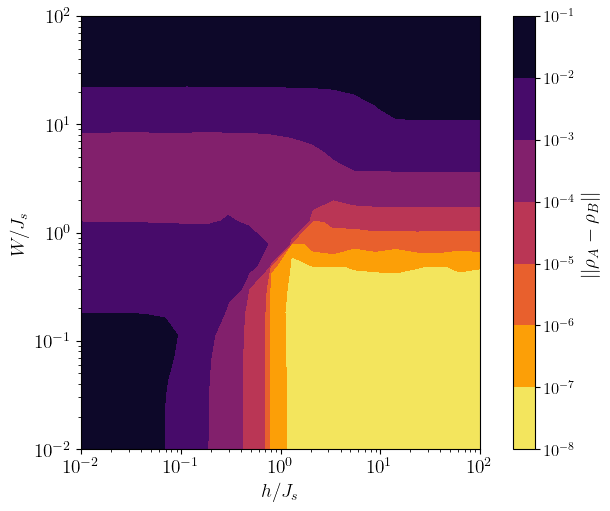

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm  # <-- Crucial Import

# Match LaTeX document font
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.figsize': (6, 5), 
    'text.usetex': True       
})

# Load / Mock Data
H = np.logspace(-2, 2, 20)
W = np.logspace(-2, 2, 20)
H, W = np.meshgrid(H, W)

# Clip lower bound values cleanly
R = np.clip(R, 1e-8, None)

# Define your explicit log boundaries
my_levels = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

# Set up constrained layout internally to prevent colorbar clipping
fig, ax = plt.subplots(figsize=(6, 5), layout='constrained')

# 1. Plot with LogNorm so the color engine scales logarithmically
cp = ax.contourf(H, W, R, levels=my_levels, cmap='inferno_r', 
                 norm=LogNorm(vmin=1e-8, vmax=1e-1))

# 2. Add the colorbar (it will automatically adopt the LogNorm ticks)
cbar = fig.colorbar(cp, ax=ax)
cbar.set_label(r'$||\rho_A - \rho_B||$', size=14)
cbar.ax.tick_params(labelsize=12)

# 3. Set Logarithmic Scales for axes
ax.set_xscale('log')
ax.set_yscale('log')

# 4. Axis Labels
ax.set_xlabel(r'$h/J_s$', size=14)
ax.set_ylabel(r'$W/J_s$', size=14)
ax.tick_params(axis='both', which='major', labelsize=14)

plt.show()

In [6]:
print(R)

[[3.02998139e-02 2.74015790e-02 2.28875982e-02 1.67072343e-02
  9.50764578e-03 3.68001643e-03 1.02011626e-03 2.10636721e-04
  3.11336538e-05 3.31995065e-07 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08]
 [2.97407057e-02 2.74952441e-02 2.31203110e-02 1.68960591e-02
  9.59666521e-03 3.70276449e-03 1.02435069e-03 2.10850346e-04
  3.11108395e-05 3.31425372e-07 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08]
 [2.80572904e-02 2.68474041e-02 2.36256202e-02 1.73962540e-02
  9.83771851e-03 3.76245783e-03 1.03469336e-03 2.11566377e-04
  3.11681711e-05 3.29081963e-07 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08
  1.00000000e-08 1.00000000e-08 1.00000000e-08 1.00000000e-08]
 [2.50951002e-02 2.45228512e-02 2.30441524e-02 1.86448709e-02
  1.0

### the observables plots

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Models import Ising, get_Pauli_Z
from Density_matrix import trace_1, mixed_density_matrix
from scipy.linalg import eigh
rng = np.random.default_rng(seed=42)

#Input: sequence of random binary numbers {0,1}
steps = 200
washout = 180
run = steps - washout
s = rng.integers(low=0,high=2,size=steps)
s_washout = s[:washout]
s_run = s[washout:]

# Defining Hamiltonian and the Initial State
N, J, h, W, tau, V =10, 1, 1, 100, 10, 100
z_ops = get_Pauli_Z(N)
Hamiltonian, _ = Ising(N,J,h,rng=rng,z_ops=z_ops,disorder=True,D=W)
rho = mixed_density_matrix(10,2,N,rng=rng,complex_ensemble=True)

#Diagonalising the Hamiltonian for time evolution
E, U = eigh(Hamiltonian)
U_dag = U.conj().T
dt = tau/V
phase_dt = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * dt)
phase_tau = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * tau)
obs_matrix = np.array([o.flatten() for o in z_ops]) 

# Defining feature extraction, input injection, and time evolution
def get_features(rho_matrix):
    # Tr(A @ B) is the dot product of A.flatten() and B.T.flatten()
    # Since observables are often Hermitian, we just use the flattened obs_matrix
    return np.real(obs_matrix @ rho_matrix.flatten())

def inpt(rho_in, s_val, N_spins):
    # Pre-calculated basis states for speed
    psi_s = np.array([np.sqrt(s_val), np.sqrt(1-s_val)]) # Simplified basis logic
    rho_s = np.outer(psi_s, psi_s)
    return np.kron(rho_s, trace_1(rho_in, N_spins))
    
def evolve(rho_in, phase_mat):
    rho_energy = U_dag @ rho_in @ U
    return U @ (rho_energy * phase_mat) @ U_dag

# Run
## Washout
for k in range(washout):
    rho = evolve(inpt(rho,s_washout[k],N),phase_mat=phase_tau)

## Main Run (input, observe, evolve)
observables = np.zeros([run*V,N])
for k in range(run):
    rho = inpt(rho,s_run[k],N)
    for i in range(V):
        observables[k*V + i,:] = get_features(rho)
        rho = evolve(rho,phase_mat=phase_dt)

In [ ]:
# Plot
from matplotlib.ticker import MaxNLocator
fig, ax = plt.subplots(2, 2, figsize=(6.5, 3.5), gridspec_kw={'wspace': 0.025, 'hspace': 0.05})

steps = 200
washout = 180
run = steps - washout
data = np.load('Data/observables.npz')
O_1 = data['O_1']
O_12 = data['O_12']
O_3 = data['O_3']
O_4 = data['O_4']
time_steps = np.linspace(washout*tau,steps*tau,run*V)

ax[0,0].plot(time_steps,O_4,lw=1.5)
ax[0,1].plot(time_steps,O_12,lw=1.5)
ax[1,0].plot(time_steps,O_3,lw=1.5)
ax[1,1].plot(time_steps,O_1,lw=1.5)

yticks = [-1,-0.5,0,0.5,1]

ax[0,0].set_ylabel(r'$\langle \sigma^z \rangle$')
ax[1,0].set_ylabel(r'$\langle \sigma^z \rangle$')
ax[1,0].set_xlabel(r'$J_st$')
ax[1,1].set_xlabel(r'$J_st$')

ax[0,0].set_yticks(ticks=yticks)
ax[1,0].set_yticks(ticks=yticks)
ax[0,0].set_xticks([])
ax[0,1].set_xticks([])
ax[0,1].set_yticks([])
ax[1,1].set_yticks([])

ax[1,1].xaxis.set_major_locator(MaxNLocator(nbins=4))
ax[1,0].xaxis.set_major_locator(MaxNLocator(nbins=4))

for i in range(2):
    for j in range(2):
        ax[i,j].set_xlim(1805,1865)

plt.savefig('Data/observables.pgf')

## Time Series Prediction using the Taken's embedding theorem, MLP, and residue prediction.

In [ ]:
## Imports and data generation
import numpy as np
import matplotlib.pyplot as plt

## Generating the MG series of 1000 steps
sigma, tau_MG, steps, discard = 0.1, 17, 1000, 1000
A = np.zeros((steps+discard)*10)
A[0] = 1.2
delay_idx = int(tau_MG / sigma)

for i in range((steps+discard)*10 - 1):
    # Using 1.2 as history to avoid the fixed-point at 0
    delayed_val = A[i - delay_idx] if i >= delay_idx else 1.2
    A[i+1] = A[i] + sigma * ((0.2 * delayed_val) / (1 + delayed_val**10) - 0.1 * A[i])

# Subsample with unit time steps
x = A[discard*10::10]

In [ ]:
# Reconstructing the Phase space
D = 3
T = 7
N = steps//2
y = np.zeros([N-(D-1)*T,D])
for i in range(N-(D-1)*T):
    for j in range(D):
        y[i,:] = x[i:i+(D-1)*T+1:T]

In [ ]:
# Plotting the reconstructed phase space trajectory
# 1. Force bold fonts globally for clean academic viewing
plt.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold'
})

# 2. Defining x, y, and z axis coordinates for clarity
x1 = y[:500,0]
x2 = y[:500,1]
x3 = y[:500,2]

# 3. Initialize the figure and add a 3D subplot
fig = plt.figure(figsize=(8, 6), layout='constrained')
ax = fig.add_subplot(111, projection='3d')

# 4. Plot the 3D curve
# 'color' sets the line color, 'lw' sets line width
ax.plot3D(x1, x2, x3, color='blue', lw=1, label=r'Reconstructed phase space of MG series')

# 5. Add bold LaTeX labels and titles
#ax.set_title("3D Space Curve Exploration", fontsize=16, pad=15)
ax.set_xlabel(r'$\mathbf{x(t)}$', fontsize=12, labelpad=10)
ax.set_ylabel(r'$\mathbf{x(t+T)}$', fontsize=12, labelpad=10)
ax.set_zlabel(r'$\mathbf{x(t+2T)}$', fontsize=12, labelpad=10)

ax.set_xlim(0.4,1.4)
ax.set_ylim(0,1.5)
ax.set_zlim(0.4,1.4)

# 6. Make tick marks bold manually
ax.tick_params(axis='both', which='major', labelsize=10)

# Optional: Adjust the viewing perspective angle (elevation, azimuth)
ax.view_init(elev=20, azim=-110)

ax.legend(fontsize=11)
plt.show()

In [ ]:
## MLP: Data and definitions
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
## Defining the MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(MLP, self).__init__()
        # Small MLP Architecture
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Input: Number of observables
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), # Optional second layer
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim)  # Output: Task dependent
        )
        
    def forward(self, x):
        return self.network(x)


def predict_single(sample_array, model):
    """
    sample_array: a single reservoir state (or vector)
    """
    model.eval()
    with torch.no_grad():
        # 1. Convert to tensor
        sample_tensor = torch.tensor(sample_array, dtype=torch.float32)
        
        # 2. Add batch dimension if it's a flat 1D array
        if sample_tensor.ndim == 1:
            sample_tensor = sample_tensor.unsqueeze(0)
        
        # 3. Predict
        prediction = model(sample_tensor)
        
        # 4. FIX: Convert the entire tensor to a numpy array and flatten/squeeze it
        # This safely handles 1 output, 3 outputs, or any dimension D.
        return prediction.cpu().numpy().squeeze()
    
## Preparing Training Data
X = y[:-1,:]    #input
Y = y[1:,:]     #target output

# Split data: 80% Training, 20% Validation
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, random_state=42)

# Convert to Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32)

# Create a dataset and loader for batching
dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# model
model = MLP(input_dim=D, hidden_dim=5, output_dim=D)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)



In [ ]:
## Genetic Algorithm : Definitions

# Create Population
import random
rng = np.random.default_rng(seed=42)

def create_population(pop_size, chromosome_length):
    population = []
    for _ in range(pop_size):
        # Generates a list of 228 random 0s and 1s
        chromosome = [random.randint(0, 1) for _ in range(chromosome_length)]
        population.append(chromosome)
    return population

# Parameters
POPULATION_SIZE = 100  # Change this to whatever you need
CHROMOSOME_LENGTH = 228
GENE_LENGTH = 6
FRACTIONAL_BITS = 3
GENES = CHROMOSOME_LENGTH//GENE_LENGTH

# Generate
my_population = create_population(POPULATION_SIZE, CHROMOSOME_LENGTH)


# Decode Population

def decode(chromosome, gene_length=GENE_LENGTH):
    decoded_weights = []
    
    for i in range(0, len(chromosome), gene_length):
        gene_bits = chromosome[i:i+gene_length]
        bit_string = "".join(map(str, gene_bits))
        
        # 1. Convert 6 bits to integer (0 to 63)
        integer_val = int(bit_string, 2)
        
        # 2. Map linearly to [-1.0, 1.0]
        # (integer_val / 63.0) gives a number between 0.0 and 1.0
        # Multiplying by 2 and subtracting 1 shifts it to [-1.0, 1.0]
        weight = -1.0 + (integer_val / 63.0) * 2.0
        
        decoded_weights.append(weight)
        
    return decoded_weights

def set_parameters(chromosome):
    # 1. Decode and reshape into NumPy arrays
    w1 = np.array(decode(chromosome[:15*6])).reshape(3, 5).T
    b1 = np.array(decode(chromosome[15*6:20*6]))
    w2 = np.array(decode(chromosome[20*6:35*6])).reshape(5, 3).T
    b2 = np.array(decode(chromosome[35*6:38*6]))
    # 2. Inject weights without tracking gradients
    with torch.no_grad():
        model.network[0].weight.copy_(torch.tensor(w1, dtype=torch.float32))
        model.network[0].bias.copy_(torch.tensor(b1, dtype=torch.float32))
        
        model.network[4].weight.copy_(torch.tensor(w2, dtype=torch.float32))
        model.network[4].bias.copy_(torch.tensor(b2, dtype=torch.float32))


## Assesing fitness of a chromosome
# chromosome to w1,b1,w2,b2
def fitness(chromosome, model=model, criterion=criterion, X_val_tensor=X_val_tensor, Y_val_tensor=Y_val_tensor):
    # 1. Decode and reshape into NumPy arrays
    w1 = np.array(decode(chromosome[:15*6])).reshape(3, 5).T
    b1 = np.array(decode(chromosome[15*6:20*6]))
    w2 = np.array(decode(chromosome[20*6:35*6])).reshape(5, 3).T
    b2 = np.array(decode(chromosome[35*6:38*6]))

    # 2. Inject weights without tracking gradients
    with torch.no_grad():
        model.network[0].weight.copy_(torch.tensor(w1, dtype=torch.float32))
        model.network[0].bias.copy_(torch.tensor(b1, dtype=torch.float32))
        
        model.network[4].weight.copy_(torch.tensor(w2, dtype=torch.float32))
        model.network[4].bias.copy_(torch.tensor(b2, dtype=torch.float32))

        # 3. Evaluate directly on validation data
        model.eval() 
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, Y_val_tensor)

    # Returning loss (Lower is better for fitness evaluation)
    return val_loss.item()

def tournament_selection(population, fitness_scores, tournament_size=3):
    """
    Selects one winning chromosome using a tournament.
    fitness_scores: a list/array of loss values corresponding to the population.
    """
    # Pick random indices from the population to enter the tournament
    chosen_indices = rng.choice(len(population), size=tournament_size, replace=False)
    
    # Find the index with the MINIMUM loss (best fitness)
    best_index = chosen_indices[np.argmin([fitness_scores[i] for i in chosen_indices])]
    
    return population[best_index]

def crossover(parent1, parent2, gene_length = GENE_LENGTH):
    n_genes = len(parent1)//gene_length
    if rng.uniform() < 0.3:
        return parent1, parent2
    else:
        i = rng.choice(n_genes-1)
        child1 = parent1[:(i+1)*gene_length] + parent2[(i+1)*gene_length:]
        child2 = parent2[:(i+1)*gene_length] + parent1[(i+1)*gene_length:]
        return child1, child2

def mutate(child, mutation_rate=0.01):
    for i in range(len(child)):
        if rng.uniform() < mutation_rate:
            child[i] ^= 1
    return child

In [ ]:
## Genetic Algorithm: The Algorithm

# 1. Evaluate the entire population
fitness_scores = [fitness(chrom) for chrom in my_population]

# 2. Track your absolute best individual (Elitism)
best_idx = np.argmin(fitness_scores)
best_chromosome = my_population[best_idx]
best_loss = fitness_scores[best_idx]
print(f"Zeroeth Generation Best Loss: {best_loss:.6f}")

n_iterations=30
for i in range(n_iterations):
    # 3. Breed the next generation
    next_generation = [best_chromosome] # Carry over the best individual automatically

    while len(next_generation) < len(my_population):
        # Select two parents using tournament selection
        parent1 = tournament_selection(my_population, fitness_scores, tournament_size=3)
        parent2 = tournament_selection(my_population, fitness_scores, tournament_size=3)
        
        # Crossover
        child1, child2 = crossover(parent1, parent2) # Implement your crossover logic here
        
        # Mutation
        child1 = mutate(child1) # Implement your mutation logic here
        child2 = mutate(child2)
        
        next_generation.append(child1)
        if len(next_generation) < len(my_population):
            next_generation.append(child2)

    my_population = next_generation
    
    # 1. Evaluate the entire population
    fitness_scores = [fitness(chrom) for chrom in my_population]

    # 2. Track your absolute best individual (Elitism)
    best_idx = np.argmin(fitness_scores)
    best_chromosome = my_population[best_idx]
    best_loss = fitness_scores[best_idx]
    print(f"Generation Best Loss: {best_loss:.6f} at index: {best_idx}")

In [ ]:
## MLP: Refining the best chromosome using gradient descent

# Hyperparameters
num_epochs = 2000

## SET THE INITIAL WEIGHTS TO THE BEST CHROMOSOME !!!!!!!!!!!!!!!!!!!!!!!!!
set_parameters(my_population[best_idx])

# Train and validate!
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        # 1. Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        
        # 2. Backward pass (the "learning" part)
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()        # Calculate new gradients
        optimizer.step()       # Update weights
        
        epoch_loss += loss.item()
    
    # Validation Check
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_tensor)
        val_loss = criterion(val_preds, Y_val_tensor)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Loss: {epoch_loss/len(train_loader):.4f} | Val Loss: {val_loss.item():.4f}")

In [ ]:
## Evaluation
y_pred = np.zeros([500,D])
y_pred[0,:] = predict_single(Y[-1], model)
for k in range(1,500):
    y_pred[k,:] = predict_single(y_pred[k-1,:],model)

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_pred[:,D-1],label='prediction')
plt.plot(x[500:],label='original')
plt.legend()

## The Sine wave test for different regions of the phase space

### For fully connected transverse field Ising model

In [ ]:
# Sin wave input test
import numpy as np
from scipy.linalg import eigh
from Models import get_Pauli_X, get_Pauli_Y, get_Pauli_Z, get_ZZ, Ising 
from Density_matrix import trace_1, mixed_density_matrix

rng = np.random.default_rng(seed=42)

# --- 1. DATA GENERATION (sin(n/5)) ---
washout, train = 500, 100
total_steps = washout + train 
time_steps = np.linspace(0,total_steps-1,total_steps)
#s = (np.sin(time_steps/5) + 1)/2
s = np.zeros(total_steps)
s[washout+9] = 1
s_washout = s[:washout]
s_train = s[washout:washout+train]

# --- 2. MODEL SETUP ---
N, J, h_val, tau = 10, 1, 0.5*(10**-2), 10
x_ops = get_Pauli_X(N)
y_ops = get_Pauli_Y(N)
z_ops = get_Pauli_Z(N)
zz_ops = get_ZZ(N,z_ops)
Hamiltonian, _ = Ising(N, J, h_val, rng, x_ops=x_ops, z_ops=z_ops)
rho = mixed_density_matrix(10, 2, N, rng, complex_ensemble=True)

E, U = eigh(Hamiltonian)
U_dag = U.conj().T
phase_factors = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * tau)

# --- 3. VECTORIZE OBSERVABLES ---
# We flatten observables into (n_obs, dim**2) to use dot products instead of Tr(rho @ O)
raw_obs = x_ops + y_ops + z_ops + zz_ops
obs_matrix = np.array([o.flatten() for o in raw_obs]) 

def get_features(rho_matrix):
    # Tr(A @ B) is the dot product of A.flatten() and B.T.flatten()
    # Since observables are often Hermitian, we just use the flattened obs_matrix
    return np.real(obs_matrix @ rho_matrix.flatten())

def time_evolve_fast(rho_0):
    rho_energy_t = (U_dag @ rho_0 @ U) * phase_factors
    return U @ rho_energy_t @ U_dag

def inpt_fast(rho_in, s_val, N_spins):
    # Pre-calculated basis states for speed
    psi_s = np.array([np.sqrt(s_val), np.sqrt(1-s_val)]) # Simplified basis logic
    rho_s = np.outer(psi_s, psi_s)
    return np.kron(rho_s, trace_1(rho_in, N_spins))

# --- 4. EXECUTION LOOPS ---

# Washout (No data storage)
for val in s_washout:
    rho = time_evolve_fast(inpt_fast(rho, val, N))

# Training (Vectorized feature extraction)
X_train = np.zeros((train, len(raw_obs)))
for k in range(train):
    rho = time_evolve_fast(inpt_fast(rho, s_train[k], N))
    X_train[k, :] = get_features(rho)

In [ ]:
#np.save('Data/X_spike_III.npy',X_train)

In [ ]:
#import numpy as np
#X_train = np.load('Data/X_spike_III-IV.npy')

In [ ]:
import matplotlib.pyplot as plt
n_rows = 3
n_columns = 4
fig, ax = plt.subplots(n_rows, n_columns, figsize=(12, 6), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

#obs = np.array([[0,1,2,10],[11,12,20,21],[22,30,31,32]])
obs = np.array([[0,10,20,30],[1,11,21,31],[2,12,22,32]])
for i in range(n_rows):
    for j in range(n_columns):
        #ax[i,j].plot(time_steps[washout:],X_train[:,obs[i,j]])
        ax[i,j].plot(X_train[:,obs[i,j]])
        #ax[i,j].set_xlim(500,657.1)
        #ax[i,j].set_xlim(0,157.1)
        #ax[i,j].set_ylim(-1,1)

for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

### For Ising ID NN

In [1]:
import numpy as np
from Density_matrix import mixed_density_matrix, trace_1
from Models import Ising_1DNN, get_Pauli_X, get_Pauli_Y,get_Pauli_Z, get_ZZ
from scipy.linalg import eigh

In [2]:
# Sin wave input test
rng = np.random.default_rng(seed=42)

# --- 1. DATA GENERATION (sin(n/5)) ---
washout, train = 500, 100
total_steps = washout + train 
time_steps = np.linspace(0,total_steps-1,total_steps)
#s = (np.sin(time_steps/5) + 1)/2
s = np.zeros(total_steps)
s[washout+9] = 1
s_washout = s[:washout]
s_train = s[washout:washout+train]

# --- 2. Initial State
N,J,h,tau=10,1,0.5,10
rho = mixed_density_matrix(10, 2, N, rng, complex_ensemble=True)
Hamiltonian, _ = Ising_1DNN(N,J,h,rng)
E, U = Hamiltonian.eigh()
U_dag = U.conj().T
phase_mat = np.exp(-1j * (E[:, np.newaxis] - E[np.newaxis, :]) * tau)

# --- 3. VECTORIZE OBSERVABLES ---
# We flatten observables into (n_obs, dim**2) to use dot products instead of Tr(rho @ O)
x_ops = get_Pauli_X(N)
y_ops = get_Pauli_Y(N)
z_ops = get_Pauli_Z(N)
zz_ops = get_ZZ(N,z_ops)
raw_obs = x_ops + y_ops + z_ops + zz_ops
obs_matrix = np.array([o.flatten() for o in raw_obs]) 

def get_features(rho_matrix):
    # Tr(A @ B) is the dot product of A.flatten() and B.T.flatten()
    # Since observables are often Hermitian, we just use the flattened obs_matrix
    return np.real(obs_matrix @ rho_matrix.flatten())

def evolve(rho_in, phase_mat):
            rho_energy = U_dag @ rho_in @ U
            return U @ (rho_energy * phase_mat) @ U_dag

def input_map(rho_in, s, N):
    """Map input s to the first spin and trace out the rest using the module's reshape trick."""
    psi_s = np.array([np.sqrt(1-s), np.sqrt(s)], dtype=complex)
    rho_s = np.outer(psi_s, psi_s.conj())
    # Use optimized partial trace from Density_matrix
    rho_rest = trace_1(rho_in, N)
    return np.kron(rho_s, rho_rest)

# --- 4. EXECUTION LOOPS ---

# Washout
for val in s_washout:
    rho = evolve(input_map(rho, val, N),phase_mat)

# Training (Vectorized feature extraction)
X_train = np.zeros((train, len(raw_obs)))
for k in range(train):
    rho = evolve(input_map(rho, s_train[k], N),phase_mat)
    X_train[k, :] = get_features(rho)

Symmetry checks passed!


In [ ]:
#np.save('Data/X_spike_1DNN.npy',X_train)

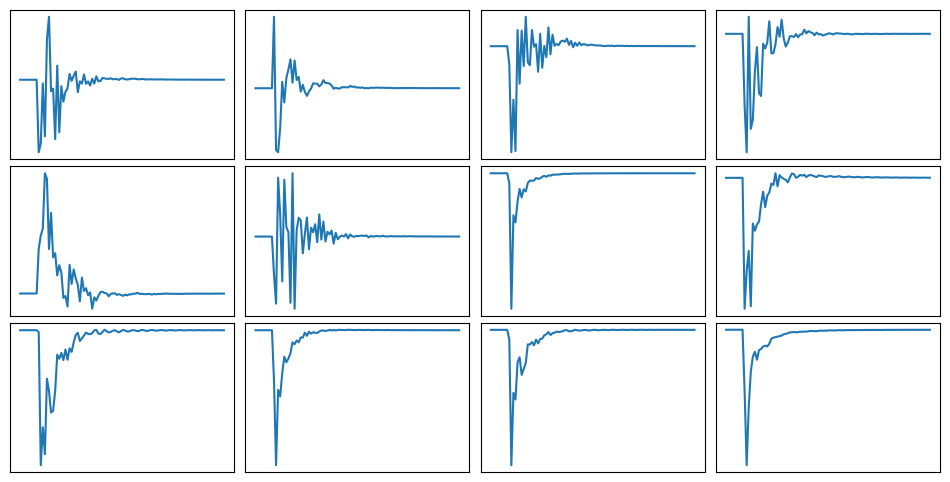

In [15]:
import matplotlib.pyplot as plt
n_rows = 3
n_columns = 4
fig, ax = plt.subplots(n_rows, n_columns, figsize=(12, 6), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})

obs = np.array([[0,1,2,10],[11,12,20,21],[22,30,31,32]])
for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].plot(time_steps[washout:],X_train[:,obs[i,j]])
        #ax[i,j].set_xlim(500,657.1)

for i in range(n_rows):
    for j in range(n_columns):
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

### For ESN of 100 unit standard sigmoid network

In [ ]:
## Defining the network and the update rule
import numpy as np
from numpy.linalg import eigvals
from numpy import typing as npt
from typing import Annotated, Literal
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=42)

N = 100 #internal units
K = 1   #input units
L = 1   #output units

#Weights. N internal units. 1 input unit. 1 output unit.

W = rng.choice([0,-0.4,0.4],size=[N,N],p=[0.95,0.025,0.025])

eigval = eigvals(W)
print('|lambda_max| =',abs(max(eigval)))

W_in = rng.choice([-1,1],size=[N,K])  #input connections


# Update rule
def update(x,u) -> npt.NDArray[np.float64]:
    x = np.tanh(W_in @ u + W @ x)
    return x 

#Output
def output(W_out,x,u,y,f=None) -> npt.NDArray[np.float64]:
    a = np.concatenate((x,u,y),axis=0)
    if f is None:
        return W_out @ a
    else:
        return f(W_out @ a)

In [ ]:
# Data Generation
washout, train = 100, 200
n = np.linspace(1,300,300)
s = np.sin(n/5)
s_washout = s[:washout]
s_train = s[washout:]

In [ ]:
# Run
## Washout Phase
x = np.zeros([N,1])
for s_val in s_washout:
    x = update(x,s_val.reshape(K,1))

## Training Phase
X = np.zeros([train,N])
for k in range(train):
    x = update(x,s_train[k].reshape(K,1))
    X[k,:] = x[:,0]

In [ ]:
import numpy as np
X = np.load('Data/X_ESN.npy')

In [ ]:
# Plot
fig, ax = plt.subplots(3,4,figsize=(10,5), gridspec_kw={'wspace': 0.05, 'hspace': 0.05})
#unit_idx = np.array([[0,11,21,31],[51,61,71,81]])
unit_idx = rng.choice(100,size=[3,4])
print(unit_idx)
for i in range(3):
    for j in range(4):
        ax[i,j].plot(X[:,unit_idx[i,j]])
        ax[i,j].set_xlim(0,157.1)
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

## ROUGH

In [ ]:
from quspin.operators import hamiltonian
from quspin.basis import spin_basis_1d, spin_basis_general
import numpy as np
from scipy.linalg import eigh

In [ ]:
N, J = 3, 1
s = np.arange(N)
Z = -(s+1)
basis = spin_basis_general(N,zblock=(Z,1))
#basis = spin_basis_general(N)

In [ ]:
rng = np.random.default_rng(seed=42)
h, W = 0.5*1e2, 0
J_ij = rng.uniform(low=-J/2,high=J/2,size=N-1)
D_i = rng.uniform(low=-W,high=W,size=N)
J_zz =  [[J_ij[i],i,i+1] for i in range(N-1)]
h_x = [[D_i[i],i] for i in range(N)]
static = [['zz',J_zz],['x',h_x]]
H = hamiltonian(static,[],basis=basis,dtype=np.float64,check_herm=False,check_symm=False)
E = H.eigvalsh()
E = np.sort(E)
delta = np.diff(E)
MIN = np.minimum(delta[:-1],delta[1:])
MAX = np.maximum(delta[:-1],delta[1:])
r = MIN/MAX
print(np.mean(r))

In [ ]:
E, U = H.eigh()


In [ ]:
from Models import Heisenberg_1DNN
import numpy as np
rng=np.random.default_rng(seed=42)

In [ ]:
N,J,h = 3,1,0.5
H = Heisenberg_1DNN(N,h,J,rng)

In [2]:
import numpy as np
rng = np.random.default_rng(seed=42)
a=0
print(rng.uniform(low=-a,high=a,size=10))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
